# Brain Tumor MRI Dataset - Exploratory Data Analysis

This notebook performs an exploratory analysis of the Brain Tumor MRI dataset.

Objectives:
- Understand dataset structure
- Count images per class
- Visualize class distribution
- Inspect image sizes
- Display sample images

In [1]:
import os
from pathlib import Path

import cv2
import numpy as numpy
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

from PIL import Image

plt.style.use("ggplot")

In [2]:
DATA_DIR = Path("../data/raw")
TRAIN_DIR = DATA_DIR/"Training"
TEST_DIR = DATA_DIR /"Testing"

In [4]:
classes = sorted(os.listdir(TRAIN_DIR))
train_counts = {}
test_counts = {}

for cls in classes:
    train_counts[cls] = len(os.listdir(TRAIN_DIR/ cls))
    test_counts[cls] = len(os.listdir(TEST_DIR / cls))

train_df = pd.DataFrame({
    "Class": train_counts.keys(),
    "Training Images": train_counts.values(),
    "Testing Images": test_counts.values()
})

train_df

,Class,Training Images,Testing Images
0,glioma,1400,400
1,meningioma,1400,400
2,notumor,1400,400
3,pituitary,1400,400


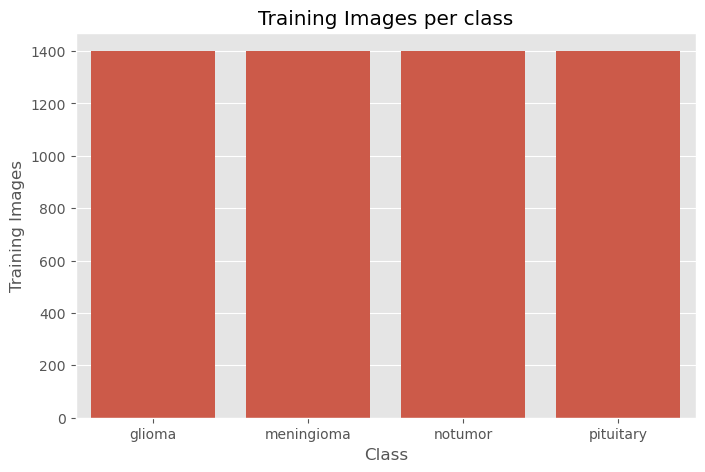

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=train_df, 
    x = "Class", 
    y = "Training Images"
)
plt.title("Training Images per class")
plt.show()

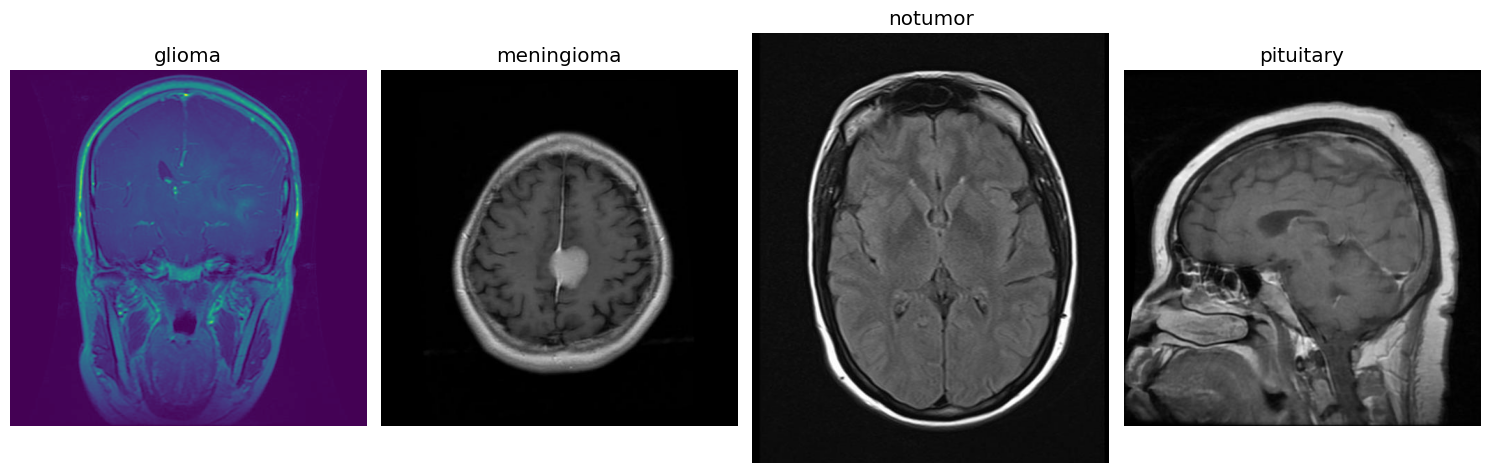

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15,5))

for ax, cls in zip(axes, classes):

    img_path = next((TRAIN_DIR / cls).iterdir())

    image = Image.open(img_path)

    ax.imshow(image)

    ax.set_title(cls)

    ax.axis("off")

plt.tight_layout()

In [7]:
sizes = [] 
for cls in classes: 
    folder = TRAIN_DIR / cls
    for img_name in os.listdir(folder): 
        img = Image.open(folder / img_name) 
        sizes.append(img.size) 
sizes[:10]

[(512, 512),
 (512, 512),
 (512, 512),
 (512, 512),
 (512, 512),
 (512, 512),
 (512, 512),
 (512, 512),
 (512, 512),
 (512, 512)]

In [8]:
pd.Series(sizes).value_counts().head(10)

(512, 512)    4012
(225, 225)     253
(630, 630)      69
(201, 251)      40
(236, 236)      39
(442, 442)      38
(150, 198)      33
(232, 217)      32
(228, 221)      32
(428, 417)      31
Name: count, dtype: int64

In [9]:
img = Image.open(next((TRAIN_DIR / classes[0]).iterdir()))
print(img.mode)

L
